## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 10.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


* 설치 후 세션 다시 시작

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

* 함수 생성

In [3]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(val_ds['text'], return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [4]:
# 데이터 예측 함수
def predict(text, model, tokenizer):
    # 입력 문장 토크나이징
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {key: value for key, value in inputs.items()}  # 각 텐서를 GPU로 이동

    # 모델 예측
    with torch.no_grad():
        outputs = model(**inputs)

    # 로짓을 소프트맥스로 변환하여 확률 계산
    logits = outputs.logits
    probabilities = logits.softmax(dim=1)

    # 가장 높은 확률을 가진 클래스 선택
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities

### (2) 구글드라이브 연결

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
path = '/content/drive/MyDrive/mini-project-6-1/'

### (3) 데이터 로딩

In [15]:
def create_dataframe(text_data: str):
    # 각 문장을 줄바꿈 기준으로 분리
    lines = text_data.splitlines()

    # 각 줄에서 문장과 라벨을 분리하여 리스트로 저장
    data = []
    for line in lines:
        # 문장과 라벨을 공백으로 구분
        parts = line.rsplit(" ", 1)
        if len(parts) == 2:
            text, label = parts
            data.append((text, int(label)))  # 텍스트와 라벨을 튜플로 저장

    # 데이터프레임 생성
    df = pd.DataFrame(data, columns=["text", "label"])

    return df

In [47]:
text_data = """
환자가 심각한 호흡곤란으로 숨을 쉬기 어려워하며 피부가 푸르스름하게 변색된 상태                                        1
환자가 얼굴이 창백하고 식은땀을 흘리며 맥박이 거의 잡히지 않는 쇼크 상태                                              1
환자가 바닥에 쓰러져 의식을 잃었고, 주변의 소리에 반응하지 않으며, 몸이 움직이지 않는 상태                                1
심장마비로 인해 환자가 갑작스럽게 가슴을 부여잡고 쓰러지며, 호흡이 중단된 상태                                          1
음주와 무관하게 갑자기 의식을 잃고 눈을 뜨지 못하며 호흡이 어려운 상태                                                1
무호흡으로 인해 환자가 전혀 숨을 쉬지 못하고, 피부가 회색으로 변색된 상태                                             1
환자가 심한 가슴 통증을 호소하며, 심장박동이 불규칙해지고 혈압이 급격히 떨어진 상태                                       1
강한 복부 통증으로 환자가 땅에 쓰러져 신음하며, 혈액이 토사물에서 발견된 상태                                           1
환자가 두통을 호소하며 갑자기 의식을 잃고, 손과 발이 심하게 떨리는 상태                                               1
응급 현장에서 환자가 강한 전기 쇼크를 받고 무의식 상태에 빠진 상태                                                     1
차 사고 후 환자가 의식을 잃고, 피를 흘리며 다리에서 심한 출혈이 지속되는 상태                                           1
환자가 급성 알레르기 반응으로 얼굴이 부어오르고 호흡이 막히는 상태                                                     1
환자가 교통사고로 가슴과 배를 심하게 다친 후, 숨을 거의 쉬지 못하는 상태                                               1
환자가 심한 복통을 호소하며, 배를 눌렀을 때 심한 통증과 함께 복부가 딱딱해진 상태                                         1
의식이 희미해지며 갑작스러운 혈압 강하로 인해 환자가 어지러워 쓰러진 상태                                              1
환자가 급성 뇌졸중 증상으로 갑자기 한쪽 몸이 마비되고, 말을 하지 못하는 상태                                            1
환자가 기도에 이물질이 걸려 숨을 쉬지 못하고, 기침조차 할 수 없는 상태                                                 1
화상 사고로 인해 환자의 피부가 심하게 탄 상태로, 고통 속에서 의식을 잃어가는 상태                                         1
환자가 심한 저체온증으로 의식이 거의 없으며, 몸 전체가 떨리고 창백한 상태                                               1
환자가 갑작스러운 혈전 발생으로 다리 한쪽이 차갑고, 통증이 심해 움직일 수 없는 상태                                         1
환자가 약물 과다 복용 후 호흡이 멈추고, 의식을 잃은 상태                                                              1
심한 교통사고 후 환자의 목에서 이상한 소리가 나며, 호흡이 불규칙한 상태                                                1
환자가 물에 빠진 후 심정지 상태로 발견되어, 숨을 쉬지 않는 상태                                                       1
환자가 급성 폐부종으로 인해 극심한 숨가쁨과 가슴 통증을 호소하며, 입술이 푸르게 변색된 상태                                    1
갑작스러운 심근경색 증상으로 환자가 심한 흉통과 팔에 방사통을 느끼며 식은땀을 흘리는 상태                                        1
환자가 고속도로에서 낙상한 후, 다리에서 심한 출혈이 발생해 의식이 점점 희미해지는 상태                                      1
낙상 후 환자가 허리 통증을 호소하며, 움직일 수 없고 다리가 마비된 상태                                                 1
갑작스러운 기절로 인해 환자가 바닥에 쓰러져 눈을 감은 채 반응하지 않는 상태                                             1
강한 복통과 함께 피부가 창백해지며 구토를 하는 환자, 의식이 희미해진 상태                                                1
환자가 농약을 마신 후 구토와 함께 의식이 혼미해져 있는 상태                                                          1
산길에서 미끄러져 큰 충격을 받은 후 환자가 갈비뼈 부위에 심한 통증을 호소하며 숨을 쉬지 못하는 상태                              1
전기 감전 사고로 인해 환자가 심하게 떨리고 의식을 잃은 상태                                                          1
심각한 사고 후 환자의 머리에서 피가 흐르고, 움직임이 전혀 없는 상태                                                   1
고층 건물에서 떨어진 후 환자가 심한 통증과 함께 의식을 잃은 상태                                                     1
자동차 사고로 환자가 강하게 충격을 받은 후 의식을 잃고, 피를 토하는 상태                                               1
환자가 알레르기 반응으로 전신이 붓고, 호흡 곤란으로 인해 창백한 상태                                                    1
산악 사고로 인해 환자가 다리에 심한 골절을 입고 출혈이 멈추지 않는 상태                                               1
강한 복통으로 환자가 식은땀을 흘리며 바닥에 쓰러진 상태                                                              1
다량의 피를 흘린 후 환자가 어지러워 쓰러지고, 피부가 창백해지는 상태                                                  1
환자가 심한 흉통을 호소하며 숨을 제대로 쉴 수 없는 상태                                                            1
급성 간부전으로 인해 환자가 황달과 함께 의식을 잃은 상태                                                           1
흡입 중독으로 인해 환자가 의식을 잃고 숨을 쉬지 않는 상태                                                          1
환자가 교통사고로 인해 목을 다친 후, 팔과 다리를 움직일 수 없는 상태                                                 1
갑작스러운 두통과 함께 환자가 발작을 일으키고 의식을 잃은 상태                                                      1
화재로 인해 환자가 심하게 그을려 숨을 제대로 쉬지 못하고, 혼란스러운 상태                                              1
고열로 인해 환자가 의식을 잃고 경련을 일으키며 쓰러진 상태                                                          1
강한 복부 통증으로 환자가 구토를 멈추지 못하고, 복부가 단단해진 상태                                                 1
강한 어지러움으로 인해 환자가 서 있지 못하고 바닥에 쓰러진 상태                                                    1
환자가 갑작스러운 발작으로 온몸이 떨리고, 호흡이 어려운 상태                                                        1
환자가 심한 흉통을 호소하며 의식을 잃고, 주변 자극에 반응하지 않는 상태                                                1
강한 가슴 압박감으로 인해 환자가 숨을 쉬지 못하고, 입술이 푸르게 변한 상태                                              1
높은 곳에서 떨어진 후 환자가 의식 없이 바닥에 누워 움직이지 않는 상태                                                  1
심한 어지러움과 가슴 두근거림으로 환자가 쓰러져 의식을 잃고, 맥박이 급격히 약해진 상태                                    1
환자가 강한 복부 통증과 출혈을 동반하여 의식을 잃은 상태                                                            1
교통사고 후 환자가 다리에 심한 골절을 입고, 다리에서 피가 멈추지 않는 상태                                              1
응급실에 도착한 환자가 심각한 호흡 곤란으로 인해 산소가 필요하고, 가슴이 쥐어지는 듯한 통증을 호소하는 상태                        1
화재 사고로 인해 환자가 심하게 화상을 입고, 숨을 쉬기 어려운 상태                                                    1
환자가 복부에 심한 통증을 느끼며 구토와 출혈을 동반하여 응급 처치가 필요한 상태                                          1
심한 두통과 함께 갑자기 의식을 잃고, 눈이 돌아가는 증상을 보이는 상태                                                 1
환자가 급성 알레르기 반응으로 인해 목이 부어오르고, 숨을 쉬지 못해 청색증을 보이는 상태                                     1
산사태 사고 후 흙더미 아래에서 발견된 환자가 심하게 압박된 상태로 의식이 없는 상태                                       1
물에 빠진 후 환자가 물 밖으로 끌려 나왔으나, 호흡이 멈추고 맥박이 없는 상태                                           1
환자가 급성 간부전으로 인해 갑작스럽게 혼란 상태에 빠지고, 피부와 눈이 노랗게 변한 상태                                     1
고열로 인해 환자가 경련을 일으키고, 의식을 잃은 상태                                                               1
강한 복통을 호소하며 환자가 구토와 설사를 반복하며, 혈압이 급격히 떨어진 상태                                           1
약물 과다 복용으로 인해 환자가 의식을 잃고, 천천히 숨을 쉬는 상태                                                   1
갑작스러운 두통과 시야 장애로 인해 환자가 혼란에 빠지고, 의식을 잃어가는 상태                                          1
응급 구조된 환자가 심한 저체온증으로 인해 몸이 떨리고, 의식이 희미한 상태                                              1
교통사고로 환자가 머리에서 피를 흘리며 의식을 잃고, 몸을 전혀 움직이지 않는 상태                                        1
갑작스러운 흉통으로 인해 환자가 숨을 쉬지 못하고, 얼굴이 하얗게 변색된 상태                                            1
환자가 급성 폐부종 증상으로 인해 심한 호흡 곤란을 겪으며, 입술과 손끝이 청색증을 보이는 상태                                 1
강한 전기 충격을 받은 후 환자가 의식을 잃고, 경련을 일으키며 바닥에 쓰러진 상태                                          1
물에 빠진 후 심정지 상태로 발견된 환자가 인공호흡이 필요한 상태                                                     1
낙상으로 인해 환자가 두개골 골절을 입고, 의식이 전혀 없는 상태                                                      1
환자가 갑작스러운 뇌출혈로 인해 한쪽 얼굴과 팔, 다리가 마비된 상태                                                   1
화학물질에 노출된 후 환자가 심한 두통과 구토를 호소하며 의식이 혼미해진 상태                                            1
고층 건물에서 떨어진 환자가 심각한 복부 손상과 출혈로 인해 의식이 희미한 상태                                          1
강한 충격으로 환자가 갈비뼈가 부러지고, 숨을 쉴 때마다 극심한 통증을 호소하는 상태                                        1
고속도로에서 심각한 교통사고 후 환자가 다리에서 심한 출혈을 일으키고 의식이 점점 흐려지는 상태                                1
환자가 화재로 인한 연기 흡입으로 호흡이 곤란하고, 의식이 점점 희미해지는 상태                                           1
음주와 무관하게 환자가 갑자기 의식을 잃고, 호흡이 멈춘 상태                                                        1
심각한 복통과 출혈로 환자가 바닥에 쓰러져 신음하며, 피부가 창백해진 상태                                              1
낙상 후 척추 손상을 입은 환자가 다리를 전혀 움직이지 못하고, 극심한 통증을 호소하는 상태                                      1
응급 현장에서 환자가 감전 사고로 인해 의식을 잃고, 숨을 쉬지 않는 상태                                               1
환자가 물에 빠진 후 심정지 상태에서 구조되어, 호흡과 맥박이 없는 상태                                                1
강한 복부 통증으로 환자가 구토를 멈추지 못하고, 복부가 단단하게 부어오른 상태                                           1
의식이 없는 환자가 심한 출혈을 일으켜 응급 조치가 필요한 상태                                                      1
뇌졸중 증상으로 인해 환자가 말이 어눌해지고, 한쪽 팔과 다리가 전혀 움직이지 않는 상태                                      1
화재로 인해 심각한 화상을 입고, 숨을 쉬지 못해 고통스러워하는 상태                                                  1
고열로 인해 환자가 몸 전체에 경련을 일으키고, 의식이 점점 사라져 가는 상태                                             1
교통사고 후 환자가 갈비뼈 골절을 입고 숨을 쉬지 못하는 상태                                                        1
환자가 심한 출혈을 일으키며 의식을 잃고, 피부가 창백하게 변한 상태                                                  1
갑작스러운 두통과 혼란으로 인해 환자가 비틀거리며 쓰러진 상태                                                     1
심장마비로 인해 환자가 가슴을 부여잡고 쓰러져 의식을 잃은 상태                                                      1
약물 중독으로 인해 환자가 의식을 잃고 천천히 숨을 쉬며, 응급 처치가 필요한 상태                                         1
낙상으로 인해 환자가 고관절 골절을 입고, 움직일 수 없는 상태                                                      1
환자가 패혈증으로 인해 고열과 빠른 심박수를 보이며, 의식을 잃어가는 상태                                              1
강한 전기 쇼크로 환자가 쓰러져 의식을 잃고, 숨을 쉬지 않는 상태                                                     1
교통사고 후 환자가 뇌 손상을 입고 혼수 상태에 빠진 상태                                                         1
환자가 강한 가슴 통증과 현기증을 호소하며, 혈압이 불안정하게 변하는 상태                                                    2
뇌졸중이 의심되는 환자가 한쪽 팔과 다리에 힘이 들어가지 않으며, 얼굴이 비대칭적으로 변한 상태                                  2
환자가 갑작스러운 호흡 곤란과 가슴 답답함을 호소하며, 청색증이 약간 나타나는 상태                                           2
심한 어지러움과 오심을 동반한 흉통으로 환자가 말을 제대로 하지 못하고 땀을 흘리는 상태                                      2
교통사고로 인해 머리를 부딪히고 심한 두통과 혼동 상태를 보이는 환자                                                      2
환자가 강한 배 아픔을 호소하며, 복부에 딱딱한 부분이 만져지는 상태                                                      2
최근 수술 후 출혈을 보이는 환자가 현기증과 약한 어지러움을 호소하며, 혈압이 낮은 상태                                         2
갑작스러운 시력 상실과 심한 두통을 겪고 있는 환자가 혼란스러운 상태                                                      2
환자가 심한 복통을 호소하며 구토와 설사를 반복하고, 탈수 증상을 보이는 상태                                               2
고열과 발진이 동반된 환자가 근육 통증과 피로감을 호소하며 혼란 상태에 빠지는 모습                                          2
가벼운 심근경색으로 진단된 환자가 흉통과 팔에 저림을 느끼며, 통증이 점차 심해지는 상태                                       2
갑작스러운 한쪽 다리의 마비와 함께 환자가 말을 더듬고 의사소통이 어려운 상태                                              2
환자가 급성 복통을 호소하며 얼굴이 창백하고 식은땀이 나는 상태                                                        2
환자가 혼란스러워하며 자신의 위치나 시간을 인지하지 못하고, 맥박이 불규칙적인 상태                                          2
낙상 후 머리에 충격을 받은 환자가 심한 두통과 메스꺼움을 호소하며 혼란 상태를 보이는 모습                                   2
환자가 심한 가슴 통증을 겪으며 손가락 끝이 푸르게 변색되는 상태                                                       2
응급실에 도착한 환자가 숨이 차고 불규칙한 심장 박동을 보이며, 혈압이 급격히 변하는 상태                                      2
뇌출혈이 의심되어 환자가 심한 두통과 구토를 호소하며 눈동자가 비정상적으로 움직이는 상태                                      2
환자가 심한 구토와 설사로 탈수 증상을 보이며, 기운이 없고 말이 느려지는 상태                                              2
급성 천식 발작으로 인해 환자가 심하게 숨을 몰아쉬며 가슴이 답답한 상태                                                  2
환자가 심한 요통을 호소하며 다리에 감각이 없어지기 시작하는 상태                                                      2
혈압이 급격히 낮아진 환자가 어지러움을 호소하며 균형을 잡기 어려워하는 모습                                               2
환자가 혼란 상태에 빠지며 한쪽 팔과 다리가 저리고 힘이 약해지는 모습                                                   2
경미한 중독 증상으로 환자가 메스꺼움과 현기증을 호소하며 혼란스러운 상태                                                 2
환자가 고열과 근육통을 호소하며, 움직일 때마다 피로감을 느끼는 상태                                                     2
고열과 두통을 동반한 환자가 목이 뻣뻣해지며 혼란 상태를 보이는 모습                                                    2
환자가 경미한 출혈을 보이며 어지러움과 약한 구토를 호소하는 상태                                                      2
급성 충수염이 의심되는 환자가 심한 복통과 구토를 보이며, 얼굴이 창백해진 상태                                             2
응급실에 온 환자가 심한 두통과 시력 저하를 호소하며 혼란 상태에 빠지는 모습                                               2
환자가 갑작스러운 두통과 어지러움으로 인해 균형을 잡지 못하고, 시야가 흐릿해지는 상태                                        2
환자가 심한 복통을 호소하며 구토와 발열을 동반한 상태                                                              2
낙상 후 허리 통증을 호소하며 다리 저림이 발생하고, 움직이기 어려워하는 환자                                              2
가벼운 가슴 압박감을 느끼며 환자가 손발이 차갑고 청색증이 조금 보이는 상태                                               2
응급실에 도착한 환자가 얼굴이 창백하고 심한 현기증을 호소하며, 맥박이 빠르게 뛰는 상태                                      2
환자가 심한 복통과 복부 팽만을 보이며 얼굴이 창백해지고 혼란스러운 상태                                                2
뇌경색이 의심되는 환자가 갑작스럽게 말을 잇지 못하고, 한쪽 팔이 떨리는 상태                                            2
고열과 빠른 호흡을 보이며 환자가 구토를 반복하고, 기운이 빠져 혼란스러운 상태                                             2
경미한 두통과 오심을 호소하는 환자가 혼란스러운 상태에 빠지는 모습                                                    2
심한 감염으로 인해 환자가 발열과 피로감을 호소하며, 기운이 없고 머리가 아픈 상태                                           2
환자가 심한 오심과 구토를 반복하며 혼란 상태를 보이는 모습                                                        2
최근 교통사고 후 환자가 허리에 심한 통증을 호소하며 움직이기 힘든 상태                                                2
응급실에 온 환자가 심한 두통과 시야 혼란을 겪으며 의사소통이 어려워지는 모습                                             2
고열로 인해 환자가 피로감을 느끼고 식은땀을 흘리며 혼란 상태에 빠지는 상태                                               2
환자가 심한 가슴 통증과 메스꺼움을 호소하며 얼굴이 창백해지고 혼란스러운 상태                                            2
환자가 어지러움과 두통을 겪으며 혈압이 불안정하게 변하는 모습                                                      2
심한 흉통으로 환자가 움직이기 힘들어하며 숨을 쉴 때마다 통증을 호소하는 상태                                              2
환자가 최근 심한 복통을 겪으며 복부 팽만과 압통을 호소하는 상태                                                      2
고열과 오한으로 인해 환자가 혼란 상태에 빠지고 기운이 없는 상태                                                     2
환자가 어지러움과 구토를 동반한 가벼운 가슴 통증을 호소하는 상태                                                     2
급성 기관지염으로 환자가 숨을 쉴 때 쌕쌕거리는 소리를 내며, 숨이 차는 상태                                              2
환자가 피로감을 호소하며 구토와 설사를 반복하고, 탈수 증상을 보이는 상태                                                2
급성 간염으로 인해 환자가 황달과 복부 통증을 호소하며 기운이 없는 상태                                                 2
낙상 후 어지러움과 허리 통증을 호소하며 움직이기 어려워하는 환자                                                     2
응급실에 온 환자가 심한 두통과 시력 저하를 호소하며 혼란 상태에 빠지는 상태                                              2
환자가 최근 심한 복통을 겪으며 구토와 설사를 반복하는 상태                                                         2
심한 가슴 답답함과 숨 가쁨을 호소하는 환자가 얼굴이 창백해지고 혼란스러운 상태                                            2
환자가 갑작스러운 어지러움으로 인해 쓰러져 얼굴이 창백해지고 혼란 상태에 빠지는 모습                                        2
뇌졸중이 의심되어 환자가 한쪽 팔과 다리에 힘이 들어가지 않으며, 얼굴이 비대칭적인 상태                                       2
환자가 고열과 두통을 동반한 혼란 상태에 빠져 있는 모습                                                           2
응급실에 도착한 환자가 심한 현기증과 오심을 호소하며, 피부가 창백해지고 맥박이 불규칙적인 상태                                2
환자가 심한 복통과 설사로 인해 탈수 증상을 보이며 기운이 없는 상태                                                   2
환자가 두통과 시력 저하를 호소하며 혼란스러운 상태에 빠지는 모습                                                     2
고열과 두통을 겪고 있는 환자가 갑작스럽게 말을 잇지 못하고, 혼란 상태에 빠진 상태                                          2
환자가 심한 요통을 호소하며 다리 감각이 점차 사라져 가는 상태                                                      2
교통사고 후 환자가 허리에 심한 통증을 호소하며 다리가 저려 움직이기 힘든 상태                                             2
환자가 강한 가슴 통증과 현기증을 호소하며, 얼굴이 창백해지고 땀을 흘리는 상태                                              2
심한 어지러움과 구토를 동반한 두통으로 인해 환자가 혼란 상태에 빠진 상태                                                2
급성 천식으로 인해 환자가 호흡 곤란을 겪으며 가슴이 답답한 상태                                                     2
환자가 갑작스러운 어지러움으로 인해 균형을 잃고 넘어져 허리 통증을 호소하는 상태                                          2
고열로 인해 환자가 근육 통증과 피로감을 호소하며 혼란 상태에 빠진 상태                                                2
급성 간염으로 인해 환자가 황달과 피로감을 호소하며 복부 통증을 느끼는 상태                                              2
환자가 갑작스러운 어지러움으로 인해 균형을 잃고, 두통을 호소하는 상태                                                  2
응급실에 온 환자가 고열과 발진을 동반한 혼란 상태에 빠지는 모습                                                     2
교통사고로 인해 머리에 충격을 받은 환자가 혼란스러운 상태에 빠져 있는 상태                                              2
환자가 강한 배 통증과 구토를 동반하며 혼란스러운 상태로 응급실에 도착한 상태                                             2
고열로 인해 환자가 두통과 오심을 겪으며 혼란 상태에 빠져 있는 모습                                                   2
환자가 심한 가슴 통증을 겪으며 청색증이 나타나는 상태                                                          2
뇌졸중이 의심되는 환자가 한쪽 팔과 다리에 감각이 사라지고, 얼굴이 비대칭적으로 변한 상태                                      2
환자가 어지러움과 혼란을 호소하며 혈압이 급격히 변하는 상태                                                       2
응급실에 온 환자가 심한 두통과 시력 저하를 호소하며, 혼란스러운 상태에 빠지는 모습                                         2
환자가 심한 복통을 호소하며 구토를 반복하고 탈수 증상을 보이는 상태                                                   2
급성 복통을 겪고 있는 환자가 얼굴이 창백하고 식은땀을 흘리며, 구토를 반복하는 상태                                           2
환자가 고열과 혼란을 겪으며 기운이 빠져 움직이기 힘든 상태                                                        2
심한 흉통으로 환자가 움직이기 힘들어하며, 숨을 쉴 때마다 통증을 호소하는 상태                                             2
낙상 후 허리 통증을 호소하며 다리가 저려 움직이기 어려운 상태                                                     2
고열로 인해 환자가 두통과 구토를 호소하며 혼란 상태에 빠지는 모습                                                    2
환자가 심한 가슴 통증과 오심을 호소하며 얼굴이 창백해지고 혼란스러운 상태                                               2
환자가 어지러움과 구토를 동반한 가벼운 가슴 통증을 호소하는 상태                                                    2
응급실에 도착한 환자가 얼굴이 창백하고 심한 현기증을 호소하며, 맥박이 불규칙적으로 뛰는 상태                                    2
환자가 심한 복통과 설사를 동반한 탈수 증상을 보이며, 기운이 없는 상태                                                  2
급성 천식 발작으로 인해 환자가 호흡 곤란을 겪으며 가슴이 답답한 상태                                                  2
환자가 두통과 시력 저하를 호소하며 혼란스러운 상태에 빠지는 모습                                                     2
심한 두통과 현기증을 겪고 있는 환자가 혼란 상태에 빠져 말을 잘하지 못하는 상태                                            2
환자가 심한 복통을 호소하며 구토를 반복하고 탈수 증상을 보이는 상태                                                  2
급성 천식으로 인해 환자가 숨을 몰아쉬며, 가슴이 답답한 상태                                                       2
교통사고 후 머리에 충격을 받은 환자가 혼란스러운 상태에 빠져 있는 모습                                                2
환자가 강한 배 통증과 함께 구토를 반복하며, 혼란스러운 상태로 응급실에 도착한 모습                                         2
심한 흉통으로 환자가 움직이기 힘들어하며 숨을 쉴 때마다 통증을 호소하는 상태                                              2
환자가 며칠 동안 지속된 경미한 가슴 답답함과 피로감을 호소하는 상태                                                    3
손목을 삔 환자가 경미한 통증과 부기를 호소하며, 움직일 때 통증이 더 심해지는 상태                                         3
급성 기관지염으로 인해 환자가 기침과 가벼운 숨 가쁨을 호소하는 상태                                                   3
환자가 소화불량과 경미한 복통을 호소하며, 식사를 하면 통증이 더 심해지는 상태                                            3
환자가 며칠째 미열과 두통을 동반한 기침을 겪고 있는 상태                                                            3
편두통으로 인해 환자가 빛과 소리에 예민해지며, 두통이 지속되는 상태                                                   3
어지러움을 동반한 경미한 메스꺼움으로 환자가 걸을 때 균형을 잡기 어려운 상태                                           3
발목을 삔 환자가 걷기가 불편하며, 부기와 약간의 통증을 호소하는 상태                                                   3
환자가 경미한 발열과 오한을 겪으며, 두통이 지속되는 상태                                                          3
환자가 갑작스러운 어지러움으로 인해 걸을 때 균형을 잡기 어려운 상태                                                 3
요통을 호소하는 환자가 허리 부위에 지속적인 통증과 경미한 뻣뻣함을 느끼는 상태                                          3
환자가 경미한 흉통을 호소하며, 심장 박동이 약간 불규칙적으로 느껴지는 상태                                             3
소화불량과 함께 가벼운 배 아픔을 호소하는 환자가 식욕이 감소한 상태                                                  3
환자가 며칠째 두통과 피로감을 느끼며, 집중하기 어려운 상태                                                         3
급성 부비동염으로 인해 환자가 코막힘과 두통을 동반한 상태                                                          3
환자가 소화 불량과 함께 경미한 복통을 호소하며 구토를 반복하는 상태                                                  3
비염으로 인해 환자가 코막힘과 가벼운 두통을 겪고 있는 상태                                                         3
환자가 약한 기침과 미열을 동반한 감기 증상을 보이며, 기운이 없는 상태                                               3
편두통으로 인해 환자가 두통과 메스꺼움을 호소하며, 밝은 빛에 예민한 상태                                             3
환자가 며칠째 가벼운 어지러움을 호소하며, 앉았다 일어설 때 현기증을 느끼는 상태                                         3
편두통으로 인해 환자가 두통과 구역감을 호소하며, 어두운 곳에서만 안정을 찾는 상태                                        3
환자가 가벼운 발열과 근육통을 동반한 독감 증상을 호소하며, 움직이기 힘든 상태                                          3
발목을 삔 환자가 부기와 약간의 통증을 느끼며, 움직이기 어려워하는 상태                                               3
편두통으로 인해 환자가 빛과 소리에 예민해지며, 두통이 지속적으로 심해지는 상태                                          3
환자가 경미한 복통을 호소하며, 식사를 할 때마다 속이 불편해지는 상태                                                 3
요통을 호소하는 환자가 허리 부위에 통증을 느끼며 움직일 때마다 불편한 상태                                              3
환자가 가벼운 두통과 함께 소화불량을 호소하며, 식사 후 속이 더부룩해지는 상태                                           3
급성 편도염으로 인해 환자가 목이 아프고 삼키기 어려운 상태                                                        3
환자가 며칠째 경미한 발열과 두통을 겪고 있으며, 기운이 없는 상태                                                    3
환자가 두통과 메스꺼움을 호소하며, 어지러움으로 인해 걸을 때 균형을 잡기 어려운 상태                                     3
비염으로 인해 환자가 코막힘과 두통을 동반한 상태                                                               3
환자가 며칠째 경미한 어지러움을 호소하며, 앉았다 일어설 때 현기증이 심해지는 상태                                         3
경미한 소화불량으로 인해 환자가 식사 후 속이 더부룩해지는 상태                                                     3
환자가 두통과 약한 오심을 동반한 편두통을 겪고 있는 상태                                                          3
환자가 경미한 흉통을 느끼며, 호흡할 때 가슴이 답답한 상태                                                        3
급성 기관지염으로 인해 환자가 기침과 가벼운 숨 가쁨을 호소하는 상태                                                  3
환자가 며칠 동안 미열과 두통을 동반한 감기 증상을 보이며 기운이 없는 상태                                               3
소화불량과 함께 경미한 복통을 호소하는 환자가 식욕이 떨어진 상태                                                    3
편두통으로 인해 환자가 두통과 메스꺼움을 호소하며, 밝은 빛에 예민한 상태                                              3
환자가 어지러움과 경미한 두통을 겪으며 앉았다 일어설 때 현기증을 느끼는 상태                                             3
요통을 호소하는 환자가 허리 부위에 경미한 통증을 느끼며, 움직일 때 불편한 상태                                          3
환자가 며칠째 경미한 두통과 피로감을 호소하며, 집중하기 어려운 상태                                                   3
급성 부비동염으로 인해 환자가 코막힘과 두통을 동반한 상태                                                         3
비염으로 인해 환자가 코막힘과 가벼운 두통을 겪고 있는 상태                                                        3
환자가 가벼운 기침과 미열을 동반한 감기 증상을 보이며, 기운이 없는 상태                                               3
편두통으로 인해 환자가 두통과 메스꺼움을 호소하며, 어두운 곳에서만 안정을 찾는 상태                                        3
환자가 어지러움을 동반한 경미한 메스꺼움으로 인해 걸을 때 균형을 잡기 어려운 상태                                         3
요통을 호소하는 환자가 허리 부위에 통증을 느끼며 움직일 때마다 불편한 상태                                              3
환자가 며칠째 두통과 피로감을 느끼며, 집중하기 어려운 상태                                                        3
급성 부비동염으로 인해 환자가 코막힘과 두통을 동반한 상태                                                         3
환자가 소화불량과 함께 경미한 복통을 호소하며 구토를 반복하는 상태                                                   3
편두통으로 인해 환자가 두통과 구역감을 호소하며, 어두운 곳에서만 안정을 찾는 상태                                        3
환자가 가벼운 발열과 근육통을 동반한 독감 증상을 호소하며, 움직이기 힘든 상태                                          3
환자가 경미한 발열과 오한을 겪으며, 두통이 지속되는 상태                                                          3
비염으로 인해 환자가 코막힘과 두통을 동반한 상태                                                               3
환자가 어지러움을 동반한 경미한 메스꺼움으로 인해 걸을 때 균형을 잡기 어려운 상태                                         3
발목을 삔 환자가 걷기가 불편하며, 부기와 약간의 통증을 호소하는 상태                                                  3
편두통으로 인해 환자가 빛과 소리에 예민해지며, 두통이 지속적으로 심해지는 상태                                          3
환자가 경미한 복통을 호소하며, 식사를 할 때마다 속이 불편해지는 상태                                                 3
요통을 호소하는 환자가 허리 부위에 통증을 느끼며 움직일 때마다 불편한 상태                                              3
환자가 가벼운 두통과 함께 소화불량을 호소하며, 식사 후 속이 더부룩해지는 상태                                           3
급성 편도염으로 인해 환자가 목이 아프고 삼키기 어려운 상태                                                        3
환자가 며칠째 경미한 발열과 두통을 겪고 있으며, 기운이 없는 상태                                                    3
환자가 두통과 메스꺼움을 호소하며, 어지러움으로 인해 걸을 때 균형을 잡기 어려운 상태                                     3
비염으로 인해 환자가 코막힘과 두통을 동반한 상태                                                               3
환자가 며칠째 경미한 어지러움을 호소하며, 앉았다 일어설 때 현기증이 심해지는 상태                                         3
경미한 소화불량으로 인해 환자가 식사 후 속이 더부룩해지는 상태                                                     3
환자가 두통과 약한 오심을 동반한 편두통을 겪고 있는 상태                                                          3
환자가 경미한 흉통을 느끼며, 호흡할 때 가슴이 답답한 상태                                                        3
급성 기관지염으로 인해 환자가 기침과 가벼운 숨 가쁨을 호소하는 상태                                                  3
환자가 며칠 동안 미열과 두통을 동반한 감기 증상을 보이며 기운이 없는 상태                                               3
소화불량과 함께 경미한 복통을 호소하는 환자가 식욕이 떨어진 상태                                                    3
편두통으로 인해 환자가 두통과 메스꺼움을 호소하며, 밝은 빛에 예민한 상태                                              3
환자가 어지러움과 경미한 두통을 겪으며 앉았다 일어설 때 현기증을 느끼는 상태                                             3
요통을 호소하는 환자가 허리 부위에 경미한 통증을 느끼며, 움직일 때 불편한 상태                                          3
환자가 며칠째 경미한 두통과 피로감을 호소하며, 집중하기 어려운 상태                                                   3
급성 부비동염으로 인해 환자가 코막힘과 두통을 동반한 상태                                                         3
비염으로 인해 환자가 코막힘과 가벼운 두통을 겪고 있는 상태                                                        3
환자가 가벼운 기침과 미열을 동반한 감기 증상을 보이며, 기운이 없는 상태                                               3
편두통으로 인해 환자가 두통과 메스꺼움을 호소하며, 어두운 곳에서만 안정을 찾는 상태                                        3
환자가 어지러움을 동반한 경미한 메스꺼움으로 인해 걸을 때 균형을 잡기 어려운 상태                                         3
환자가 가벼운 복통과 함께 38도 이상의 발열을 겪고 있는 상태                                                          4
환자가 경미한 복부 불편감을 느끼며, 구역질과 설사를 동반한 상태                                                        4
환자가 지속적인 가벼운 두통과 38도 이상의 발열을 겪고 있는 상태                                                     4
환자가 감기 증상과 함께 38도 이상의 발열을 동반한 상태                                                              4
환자가 어지러움을 호소하며, 가벼운 기침과 발열을 동반한 상태                                                          4
환자가 복통과 설사를 겪으며 38도 이상의 발열을 동반한 상태                                                          4
환자가 약간의 복통을 호소하며, 미열과 피로감을 느끼는 상태                                                            4
환자가 경미한 두통과 함께 식사 후 속이 불편해지는 상태                                                                4
환자가 가벼운 기침과 함께 38도 이상의 발열을 겪고 있는 상태                                                           4
환자가 약간의 소화불량과 가벼운 발열을 동반한 상태                                                                   4
환자가 경미한 복통과 발열을 동반한 상태                                                                            4
환자가 피로감과 함께 약간의 두통을 호소하는 상태                                                                    4
환자가 가벼운 기침과 함께 미열을 겪고 있는 상태                                                                     4
환자가 약간의 발열과 함께 설사를 호소하는 상태                                                                     4
환자가 경미한 복통과 함께 체중 감소를 호소하는 상태                                                                 4
환자가 가벼운 두통과 미열을 동반한 상태                                                                            4
환자가 약간의 설사와 함께 38도 이상의 발열을 호소하는 상태                                                           4
환자가 약간의 가벼운 두통과 발열을 동반한 상태                                                                    4
환자가 38도 이상의 발열을 겪으며, 가벼운 기침을 호소하는 상태                                                        4
환자가 가벼운 복통과 설사를 겪고 있으며, 발열이 있는 상태                                                           4
환자가 피로감을 느끼며 약간의 두통을 동반한 상태                                                                    4
환자가 미열과 함께 피로감을 호소하는 상태                                                                          4
환자가 약간의 설사와 발열을 겪고 있는 상태                                                                         4
환자가 경미한 소화불량과 함께 발열을 겪고 있는 상태                                                                 4
환자가 미열과 가벼운 복통을 동반한 상태                                                                           4
환자가 약간의 기침과 함께 미열을 겪고 있는 상태                                                                    4
환자가 복부 불편감과 함께 38도 이상의 발열을 겪고 있는 상태                                                           4
환자가 가벼운 두통과 함께 발열을 동반한 상태                                                                      4
환자가 경미한 복통과 설사를 겪고 있는 상태                                                                       4
환자가 약간의 발열과 기침을 동반한 상태                                                                           4
환자가 38도 이상의 발열과 함께 피로감을 호소하는 상태                                                              4
환자가 미열을 겪으며 약간의 소화불량을 호소하는 상태                                                                4
환자가 피로감을 느끼며 약간의 복통을 호소하는 상태                                                                  4
환자가 발열과 함께 소화불량을 호소하는 상태                                                                      4
환자가 약간의 설사와 발열을 동반한 상태                                                                           4
환자가 복부 불편감과 함께 미열을 겪고 있는 상태                                                                   4
환자가 약간의 기침과 함께 38도 이상의 발열을 겪고 있는 상태                                                           4
환자가 발열을 동반한 소화불량을 겪고 있는 상태                                                                   4
환자가 38도 이상의 발열과 함께 가벼운 기침을 동반한 상태                                                           4
환자가 약간의 두통과 함께 미열을 호소하는 상태                                                                   4
환자가 약간의 설사와 함께 가벼운 발열을 동반한 상태                                                                4
환자가 가벼운 기침과 발열을 동반한 상태                                                                            4
환자가 피로감과 함께 발열을 동반한 상태                                                                           4
환자가 약간의 복통과 함께 피로감을 호소하는 상태                                                                  4
환자가 가벼운 두통과 함께 소화불량을 호소하는 상태                                                                4
환자가 약간의 설사와 함께 38도 이상의 발열을 동반한 상태                                                           4
환자가 약간의 피로감을 느끼며 38도 이상의 발열을 겪고 있는 상태                                                     4
환자가 미열과 함께 약간의 두통을 호소하는 상태                                                                   4
환자가 38도 이상의 발열을 겪으며, 경미한 복통을 호소하는 상태                                                       4
환자가 약간의 설사와 함께 미열을 동반한 상태                                                                     4
환자가 복부 불편감과 함께 38도 이상의 발열을 겪고 있는 상태                                                           4
환자가 약간의 기침과 발열을 동반한 상태                                                                           4
환자가 가벼운 두통과 미열을 동반한 상태                                                                          4
환자가 약간의 설사와 함께 발열을 겪고 있는 상태                                                                   4
환자가 경미한 복통을 호소하며 발열과 소화불량을 겪고 있는 상태                                                       4
환자가 38도 이상의 발열을 겪고 있으며, 가벼운 기침을 호소하는 상태                                                   4
환자가 약간의 설사와 함께 발열을 호소하는 상태                                                                     4
환자가 가벼운 기침과 미열을 동반한 상태                                                                          4
환자가 복부 불편감과 함께 38도 이상의 발열을 겪고 있는 상태                                                         4
환자가 약간의 기침과 발열을 동반한 상태                                                                           4
환자가 38도 이상의 발열을 겪고 있으며, 가벼운 복통을 호소하는 상태                                                   4
환자가 약간의 복통과 함께 설사를 겪고 있는 상태                                                                   4
환자가 가벼운 두통과 함께 미열을 동반한 상태                                                                     4
환자가 피로감을 느끼며 약간의 복통을 호소하는 상태                                                                 4
환자가 발열과 함께 소화불량을 호소하는 상태                                                                     4
환자가 약간의 설사와 발열을 동반한 상태                                                                          4
환자가 미열과 함께 피로감을 호소하는 상태                                                                       4
환자가 가벼운 기침과 미열을 겪고 있는 상태                                                                      4
환자가 약간의 설사와 함께 38도 이상의 발열을 동반한 상태                                                          4
환자가 가벼운 복통을 동반한 상태                                                                                 4
환자가 약간의 발열과 함께 피로감을 느끼는 상태                                                                  4
환자가 경미한 복통을 겪으며 가벼운 기침을 호소하는 상태                                                           4
환자가 38도 이상의 발열을 동반한 소화불량을 겪고 있는 상태                                                        4
환자가 약간의 복통과 미열을 동반한 상태                                                                         4
환자가 가벼운 두통과 발열을 동반한 상태                                                                         4
환자가 약간의 설사와 함께 발열을 겪고 있는 상태                                                                  4
환자가 감기 증상을 겪으며 기침과 미열을 호소하는 상태                                                                5
환자가 가벼운 설사를 겪고 있으며, 특별한 증상 없이 식사 후 불편감을 느끼는 상태                                        5
환자가 가벼운 기침과 함께 콧물이 나오는 상태                                                                        5
환자가 두통을 겪고 있으며, 몸살 기운이 있지만 특별한 증상은 없는 상태                                                5
환자가 약간의 열감과 함께 피로를 느끼는 상태                                                                         5
환자가 감기 기운과 함께 기침을 하며, 특별한 호흡 곤란이 없는 상태                                                     5
환자가 가벼운 복통을 겪고 있으며, 설사를 동반하지 않는 상태                                                           5
환자가 가벼운 두통을 겪으며, 미열이 있지만 특별히 심각한 증상은 없는 상태                                           5
환자가 가벼운 기침과 콧물로 인해 불편감을 느끼는 상태                                                                5
환자가 약간의 설사와 함께 소화불량을 겪고 있는 상태                                                                  5
환자가 가벼운 발열을 동반한 콧물과 기침을 겪고 있는 상태                                                            5
환자가 약간의 소화불량을 겪으며, 식사 후 가벼운 불편감을 느끼는 상태                                                  5
환자가 경미한 기침을 동반한 가벼운 발열을 겪고 있는 상태                                                            5
환자가 약간의 배탈과 함께 피로감을 느끼는 상태                                                                       5
환자가 가벼운 두통과 미열을 겪고 있는 상태                                                                          5
환자가 약간의 피로감을 호소하며, 기침과 가벼운 발열을 겪고 있는 상태                                                 5
환자가 가벼운 복통과 설사를 겪고 있으며, 발열은 없는 상태                                                           5
환자가 약간의 두통을 호소하며 피로감을 느끼는 상태                                                                  5
환자가 가벼운 발열과 함께 기침을 하는 상태                                                                          5
환자가 가벼운 구토와 함께 식사 후 불편감을 호소하는 상태                                                           5
환자가 약간의 기침과 가벼운 두통을 겪고 있는 상태                                                                   5
환자가 가벼운 소화불량을 겪고 있으며, 특별한 증상 없이 복부 불편감을 느끼는 상태                                        5
환자가 약간의 복통을 겪고 있으며, 특별한 증상이 없는 상태                                                           5
환자가 피로감을 느끼며, 약간의 두통을 호소하는 상태                                                                  5
환자가 기침과 콧물로 인해 불편감을 겪고 있는 상태                                                                  5
환자가 약간의 가벼운 기침과 발열을 동반한 상태                                                                     5
환자가 가벼운 복통과 약간의 설사를 겪고 있는 상태                                                                  5
환자가 약간의 미열과 함께 피로감을 느끼는 상태                                                                     5
환자가 가벼운 기침과 함께 체온이 살짝 오른 상태                                                                   5
환자가 약간의 설사와 함께 소화불량을 겪고 있는 상태                                                                5
환자가 피로감을 느끼며 약간의 기침을 동반한 상태                                                                   5
환자가 약간의 두통을 겪으며, 미열과 함께 피로감을 느끼는 상태                                                      5
환자가 가벼운 기침을 동반한 상태로, 체온은 정상 범위인 상태                                                        5
환자가 약간의 배탈과 함께 피로감을 겪고 있는 상태                                                                  5
환자가 약간의 소화불량과 가벼운 복통을 겪고 있는 상태                                                              5
환자가 미열과 함께 약간의 기침을 호소하는 상태                                                                     5
환자가 약간의 복통을 동반한 상태로, 특별한 증상은 없는 상태                                                         5
환자가 가벼운 두통과 함께 몸살 기운을 느끼는 상태                                                                  5
환자가 약간의 설사를 겪으며, 특별한 증상이 없는 상태                                                              5
환자가 약간의 기침을 동반한 상태로, 체온은 정상 범위 내인 상태                                                     5
환자가 피로감을 느끼며 가벼운 두통을 겪고 있는 상태                                                                5
환자가 약간의 배탈과 함께 기침을 호소하는 상태                                                                    5
환자가 가벼운 기침을 동반한 상태로, 특별한 증상은 없는 상태                                                       5
환자가 약간의 설사와 함께 가벼운 발열을 겪고 있는 상태                                                            5
환자가 약간의 기침과 미열을 동반한 상태                                                                          5
환자가 피로감을 느끼며 약간의 기침을 동반하는 상태                                                                 5
환자가 가벼운 두통과 미열을 겪고 있는 상태                                                                        5
환자가 약간의 복통과 기침을 겪고 있는 상태                                                                       5
환자가 가벼운 기침과 함께 설사를 동반한 상태                                                                     5
환자가 약간의 피로감을 느끼며 미열을 동반하는 상태                                                                5
환자가 가벼운 설사를 겪고 있으며, 발열은 없는 상태                                                                 5
환자가 약간의 피로감과 함께 두통을 겪고 있는 상태                                                                 5
환자가 약간의 배탈과 함께 미열을 겪고 있는 상태                                                                  5
환자가 가벼운 기침과 설사를 동반한 상태                                                                          5
환자가 약간의 두통과 함께 가벼운 발열을 동반하는 상태                                                            5
환자가 약간의 설사와 피로감을 겪고 있는 상태                                                                     5
환자가 기침과 미열을 동반하며 피로감을 느끼는 상태                                                                5
환자가 가벼운 설사와 함께 피로감을 호소하는 상태                                                                  5
환자가 약간의 기침과 함께 체온이 37도 이하로 오르며 불편감을 겪는 상태                                             5
환자가 미열과 함께 가벼운 설사를 겪고 있는 상태                                                                  5
환자가 약간의 소화불량과 함께 미열을 겪고 있는 상태                                                               5
환자가 약간의 설사와 함께 가벼운 복통을 겪고 있는 상태                                                            5
환자가 기침과 함께 약간의 발열을 겪고 있는 상태                                                                  5
환자가 약간의 배탈과 함께 피로감을 느끼는 상태                                                                   5
환자가 가벼운 기침과 발열을 동반한 상태                                                                           5
환자가 약간의 복통과 설사를 겪고 있는 상태                                                                      5
환자가 미열과 함께 약간의 두통을 겪고 있는 상태                                                                  5
환자가 약간의 기침을 동반한 상태로, 체온은 정상 범위 내인 상태                                                     5
환자가 약간의 설사와 함께 피로감을 호소하는 상태                                                                 5
환자가 가벼운 발열과 함께 피로감을 겪고 있는 상태                                                                5
환자가 약간의 복통을 겪으며 기침을 동반한 상태                                                                   5
환자가 약간의 기침과 미열을 동반한 상태                                                                          5
환자가 가벼운 설사와 피로감을 겪고 있는 상태                                                                     5
환자가 약간의 두통을 호소하며, 체온이 37도 이하인 상태                                                            5
환자가 약간의 설사와 함께 미열을 겪고 있는 상태                                                                  5
환자가 가벼운 발열과 설사를 동반한 상태                                                                         5
환자가 약간의 기침과 함께 피로감을 느끼는 상태                                                                   5
환자가 미열과 함께 가벼운 기침을 동반한 상태                                                                    5
환자가 가벼운 설사와 함께 미열을 겪고 있는 상태                                                                  5
환자가 감기로 인해 가벼운 기침을 하고 있으며 컨디션이 저조한 상태 5
환자가 가벼운 감기를 호소하며 기침과 약간의 발열을 겪는 상태 5
환자가 복부 불편감과 함께 경미한 설사를 보이는 상태 5
환자가 일시적인 발열을 동반한 소화불량 상태 5
환자가 가벼운 두통과 함께 약간의 피로를 느끼는 상태 5
환자가 약간의 목 아픔과 기침을 호소하는 상태 5
환자가 단순한 감기 증세와 함께 가벼운 기침을 하는 상태 5
환자가 경미한 복통과 함께 가벼운 열을 동반하는 상태 5
환자가 약간의 기침과 목 통증을 호소하는 상태 5
환자가 가벼운 발열과 함께 약간의 피로감을 느끼는 상태 5
환자가 소화불량으로 복통을 겪고 있는 상태 5
환자가 가벼운 설사를 동반한 복통을 겪는 상태 5
환자가 경미한 두통과 함께 체온 상승을 겪고 있는 상태 5
환자가 가벼운 배탈을 호소하며 복통을 느끼는 상태 5
환자가 약간의 기침과 함께 체온 상승을 보이는 상태 5
환자가 가벼운 두통과 함께 피로감을 느끼는 상태 5
환자가 소화불량으로 배가 불편한 상태 5
환자가 작은 상처와 함께 약간의 출혈을 보이는 상태 5
환자가 기침과 함께 가벼운 인후통을 겪는 상태 5
환자가 단순한 감기로 인한 발열과 기침을 겪고 있는 상태 5
환자가 발열과 함께 약간의 구토를 동반하는 상태 5
환자가 심각한 호흡곤란으로 숨을 쉬기 어려워하며 피부가 푸르스름하게 변색된 상태 1
환자가 얼굴이 창백하고 식은땀을 흘리며 맥박이 거의 잡히지 않는 쇼크 상태 2
혈압이 불안정하고 맥박이 불규칙하여 환자가 현기증을 느끼며 균형을 잡기 어려운 상태 2
환자가 약간의 숨 가쁨을 호소하지만 대화는 가능한 상태 3
환자의 맥박이 규칙적이지 않으나 혈압은 안정적으로 유지되는 상태 3
아파 보이며 열이 나고, 감염의 초기 징후가 보이는 상태 3
건강해 보이지만 열이 나며, 가벼운 감염의 징후를 보이는 상태 3
환자가 발열과 근육통을 겪으며 감염 증상이 나타나는 상태 3
환자가 미열과 함께 소화불량 증세를 겪고 있는 상태 3
환자가 두통을 호소하며 체온이 상승한 상태 3
가벼운 발열과 함께 인후통을 호소하는 상태 3
환자가 탈수 증세를 보이며, 소변량이 급격히 줄어든 상태 3
환자가 소화불량과 함께 구토를 일으키는 상태 3
환자가 가벼운 기침과 함께 호흡이 조금 불편한 상태 3
환자가 복통을 호소하며, 급격한 소화불량 증세가 나타나는 상태 3
환자가 약간의 설사를 하며, 탈수 증세가 나타나는 상태 3
환자가 복부 팽만감을 호소하며 통증을 느끼는 상태 3
환자가 상처에서 약간의 출혈이 있는 상태 3
환자가 지속적인 기침과 인후통을 호소하는 상태 3
환자가 식사를 한 후 불편한 소화불량을 느끼는 상태 3
환자가 기침을 하며 가벼운 체온 상승을 보이는 상태 3
환자가 복통과 함께 약간의 설사를 겪는 상태 3
환자가 열과 함께 가벼운 기침을 보이는 상태 4
환자가 설사를 시작하고, 복통을 호소하는 상태 4
환자가 나이가 많고 감기 증세가 나타나는 상태 4
환자가 경미한 발열과 기침을 보이며 전염병을 의심하는 상태 4
환자가 경미한 복통과 구토 증세를 겪는 상태 4
환자가 발열과 함께 기침을 동반하는 가벼운 감기 증세를 보이는 상태 4
환자가 가벼운 기침과 함께 체온이 37도 이상 상승하는 상태 4
환자가 약간의 설사를 보이며 체온이 조금 상승한 상태 4
환자가 팔꿈치 통증을 호소하며 운동을 일시적으로 중단한 상태 4
환자가 입술에 갈라짐과 함께 약간의 출혈을 보이는 상태 4
환자가 가벼운 두통과 함께 가벼운 발열 증세를 보이는 상태 4
환자가 복통을 호소하며 평소보다 다소 불편해하는 상태 4
환자가 불규칙한 배변과 함께 가벼운 소화불량 증세를 보이는 상태 4
환자가 소화불량으로 가벼운 메스꺼움을 호소하는 상태 4
환자가 약간의 현기증과 함께 가벼운 복부 불편감을 호소하는 상태 4
환자가 나이가 많고, 기침과 발열이 동반된 상태 4
환자가 근육통을 호소하며 약간의 발열을 겪는 상태 4
환자가 불편한 소화불량을 호소하며 기운이 없는 상태 4
환자가 약간의 복통과 발열을 동반하는 상태 4
환자가 기침과 함께 가벼운 두통을 겪는 상태 4
환자가 만성적인 두통과 함께 체온 상승을 보이는 상태 4
환자가 경미한 발열을 동반하는 통증을 호소하는 상태 4
환자가 약간의 구토를 보이며 복통을 겪고 있는 상태 4
환자가 장염 증세를 보이며 가벼운 설사를 겪는 상태 4
"""

In [48]:
df = create_dataframe(text_data)

In [49]:
df.loc[df['label'] == 5]

,text,label
354,환자가 감기 증상을 겪으며 기침과 미열을 호소하는 상태 ...,5
355,"환자가 가벼운 설사를 겪고 있으며, 특별한 증상 없이 식사 후 불편감을 느끼는 상태...",5
356,환자가 가벼운 기침과 함께 콧물이 나오는 상태 ...,5
357,"환자가 두통을 겪고 있으며, 몸살 기운이 있지만 특별한 증상은 없는 상태 ...",5
358,환자가 약간의 열감과 함께 피로를 느끼는 상태 ...,5
...,...,...
449,환자가 소화불량으로 배가 불편한 상태,5
450,환자가 작은 상처와 함께 약간의 출혈을 보이는 상태,5
451,환자가 기침과 함께 가벼운 인후통을 겪는 상태,5
452,환자가 단순한 감기로 인한 발열과 기침을 겪고 있는 상태,5


In [50]:
df.to_csv('ktas.csv')

In [8]:
data = pd.read_csv(path + 'emotion.csv')
data.head()

,text,label
0,i feel the melancholy running my veins as well,sadness
1,im feeling cranky im very defensive about it,anger
2,i should feel blessed to have but what about m...,joy
3,i do know is this i have no desire to spend my...,sadness
4,im feeling awfully spiteful right now,anger


* y 분포 확인하기

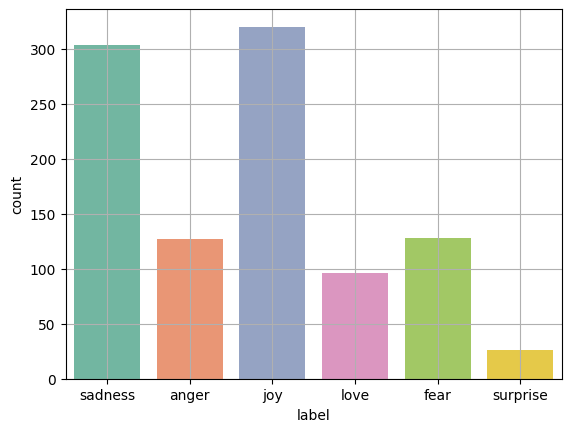

In [9]:
sns.countplot(x='label', data = data, palette='Set2')
plt.grid()
plt.show()

* label 에 대한 정수 인코딩

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])
data.head()

,text,label
0,i feel the melancholy running my veins as well,4
1,im feeling cranky im very defensive about it,0
2,i should feel blessed to have but what about m...,2
3,i do know is this i have no desire to spend my...,4
4,im feeling awfully spiteful right now,0


### (4) GPU 설정
* 파이토치를 위한 설정

In [11]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 2.데이터 준비

### (1) Dataset 만들기 : train, val

In [12]:
train, val = train_test_split(data, test_size=0.2, random_state=42)

In [13]:
# 텐서 데이터셋
train_ds = Dataset.from_pandas(train)
val_ds = Dataset.from_pandas(val)

In [14]:
train_ds[:3]

{'text': ['i am feeling so nostalgic lately i would like to say it is because i am yearning for a simpler time but those times i find myself thinking of are far from simple',
  'i feel more relaxed now that i will get good care and that i need to accept advice given to me unless i feel very strongly otherwise',
  'i have to visit them every after school and later i have to go tuition and i do not have the time to even study for my exam next week and i have a feeling that i am so going to fail a lot of my subjects and to be blamed for either not concentrating during class or not studying'],
 'label': [3, 2, 4],
 '__index_level_0__': [29, 535, 695]}

### (2) 토큰화

In [19]:
# 모델과 토크나이저 불러오기
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [20]:
# 토큰화 함수 생성 및 작업
def preprocess_function(data):
    return tokenizer(data['text'], truncation=True, padding=True)

train_ds = train_ds.map(preprocess_function, batched=True)
val_ds = val_ds.map(preprocess_function, batched=True)

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

## 3.Fine-Tuning

### (1) 사전학습 모델 준비

In [21]:
# 모델 설정 (다중 분류를 위해 num_labels 지정)
n = 6
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = n).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습

* TrainingArguments 설정
    * Hugging Face의 transformers 라이브러리에서 모델 학습에 필요한 다양한 설정을 지정하는데 사용

* 각 설정에 대한 설명
    * **output_dir = './results'**  
        * 모델 학습의 출력물(모델, 로그 파일 등)을 저장할 디렉토리
    * **eval_strategy = "epoch"**
        * 매 에폭이 끝날 때마다 평가. 평가에는 검증(validation) 데이터를 사용하여 모델의 성능을 측정
    * **save_strategy = "epoch"**  
        * 체크포인트를 언제 저장할지 결정.
        * "epoch" : 각 에폭이 끝날 때마다 체크포인트 저장
        * 체크포인트는 나중에 중단된 지점에서 학습을 재개할 수 있도록 모델의 상태를 저장
    * **weight_decay = 0.01**
        * 과적합 방지 규제(regularization) 기법 중 하나.
        * 모델의 가중치가 학습 중에 감소하는 비율
        * 일반적으로 작은 값(0.01)이 설정됩니다.
    * **logging_dir = './logs'**
        * 학습 중 로그 파일 저장 디렉토리
        * 학습 중에 성능 지표를 기록하여 시각화하거나 분석하는 데 사용
    * **report_to = "tensorboard"**
        * TensorBoard : 손실, 정확도 등 모델의 성능 지표를 그래프로 볼 수 있는 도구
        * TensorBoard로 로그를 전송하여 학습 진행 상황을 시각화할 수 있도록 설정

In [22]:
training_args = TrainingArguments(
    output_dir = './results',          # 출력 디렉토리
    eval_strategy = "epoch",            # 에폭마다 평가
    save_strategy = "epoch",           # 에폭마다 체크포인트 저장
    learning_rate = 2e-5,              # <--[조정가능]학습률
    per_device_train_batch_size = 32,  # <--[조정가능]학습 배치 사이즈
    per_device_eval_batch_size = 32,   # <--[조정가능]평가 배치 사이즈
    num_train_epochs  = 5,              # <--[조정가능]에폭 수
    weight_decay = 0.02,               # <--[조정가능]weight decay
    load_best_model_at_end = True,     # 가장 좋은 모델을 마지막에 로드
    logging_dir ='./logs',            # 로깅 디렉토리
    logging_steps = 10,                # 로깅 스텝
    report_to="tensorboard"          # TensorBoard에 로깅
)

* Trainer
    * Hugging Face의 transformers 라이브러리에서 제공하는 고수준 API로, 모델 학습과 평가를 쉽게 할 수 있도록 도와주는 클래스

In [23]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ds,
    eval_dataset = val_ds,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

In [24]:
# 모델 학습
trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# 모델 평가
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

### (3) 모델 사용

In [ ]:
text = "I'm absolutely thrilled with the way everything turned out!"
predicted_class, probabilities = predict(text)

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {le.inverse_transform([predicted_class])}")
print(f"클래스별 확률: {probabilities}")

### (4) 모델 검증평가

In [ ]:
pred, prob = evaluate(val_ds, model, device)

In [ ]:
print(confusion_matrix(val_ds['label'], pred))
print(classification_report(val_ds['label'], pred, target_names = le.classes_))